# eMule PINN — CALCE Preprocessing + Merge + Training
## Complete notebook: CALCE data + eMule data → merged PINN

**What this notebook does (in order):**
1. Loads and cleans the 6 CALCE files (DST, FUDS, US06 at 25°C)
2. Loads and cleans the eMule data (`emule_bms_raw_oem_fixed.csv`)
3. Normalises both datasets to C-rate so they are directly comparable
4. **Merges** CALCE + eMule into a single training dataset
5. Trains the TheveninPINN on the merged dataset
6. Evaluates and saves the model

**Expected folder structure:**
```
Model/
├── Data/
│   ├── SP2_25C_DST/          ← .xls files inside
│   ├── SP2_25C_FUDS/
│   ├── SP2_25C_US06/
│   └── emule_bms_raw_oem_fixed.csv
├── emule_pinn_model.py        ← copy this from your eMule notebook folder
└── calce_emule_fusion.ipynb   ← this notebook
```

### Cell 1 — Install packages

In [12]:
import subprocess, sys
for pkg in ['openpyxl', 'torch', 'scikit-learn', 'joblib', 'scipy']:
    try:
        __import__(pkg if pkg != 'scikit-learn' else 'sklearn')
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  {pkg} installed.')
print('All packages ready.')


All packages ready.


### Cell 2 — Configuration
**Only cell you need to edit** if your paths are different.

In [13]:
import warnings, os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════════
# PATHS — edit DATA_DIR if needed
# ═══════════════════════════════════════════════════════════════════
DATA_DIR    = r"./Data"                               # Data/ folder
EMULE_FILE  = r"./Data/emule_bms_raw_oem_fixed.csv"  # fixed eMule file
OUTPUT_DIR  = r"./merged_preprocessed"                # output tensors
CHECKPOINT  = r"./pinn_checkpoint_merged"             # model weights

Path(OUTPUT_DIR).mkdir(exist_ok=True)
Path(CHECKPOINT).mkdir(exist_ok=True)

# ═══════════════════════════════════════════════════════════════════
# BATTERY SPECS
# ═══════════════════════════════════════════════════════════════════
# --- CALCE INR 18650-20R ---
CALCE_CAP_AH    = 2.028   # Ah — measured from initial capacity file
CALCE_VMIN      = 2.50    # V per cell (empty)
CALCE_VMAX      = 4.20    # V per cell (full)
CALCE_TEMP      = 25.0    # °C — all CALCE tests at 25°C

# --- eMule pack (14 cells in series) ---
EMULE_CAP_AH    = 600.0   # Ah — full pack
EMULE_N_CELLS   = 14      # cells in series
EMULE_CELL_AH   = EMULE_CAP_AH / EMULE_N_CELLS   # 42.86 Ah per cell
EMULE_VMIN_CELL = 43.0 / EMULE_N_CELLS            # 3.07V per cell at 47% SOC
EMULE_VMAX_CELL = 58.0 / EMULE_N_CELLS            # 4.14V per cell at 100% SOC
SOC_FLOOR       = 47.0    # % — vehicle does not operate below this (professor constraint)

# ═══════════════════════════════════════════════════════════════════
# FEATURES — identical for both sources after normalisation
# ═══════════════════════════════════════════════════════════════════
FEATURE_COLS = [
    'voltage_cell',  # V per cell     (CALCE: direct | eMule: vbat/14)
    'ibat_crate',    # C-rate         (CALCE: I/2.028 | eMule: ibat/42.86)
    'tbat',          # °C             (CALCE: fixed 25 | eMule: measured)
    'power_norm',    # C-rate x V     (dimensionless)
    'dvdt',          # V/s            (same for both)
    'elapsed_s',     # s              (reset per session)
]
TARGET_COLS  = ['soc_coulomb']

print(f"DATA_DIR      : {DATA_DIR}")
print(f"EMULE_FILE    : {EMULE_FILE}")
print(f"OUTPUT_DIR    : {OUTPUT_DIR}")
print()
print(f"CALCE cell    : {CALCE_CAP_AH} Ah | V {CALCE_VMIN}–{CALCE_VMAX}V")
print(f"eMule cell    : {EMULE_CELL_AH:.2f} Ah | V {EMULE_VMIN_CELL:.2f}–{EMULE_VMAX_CELL:.2f}V")
print(f"C-rate factor : {EMULE_CELL_AH/CALCE_CAP_AH:.1f}x  (why we normalise to C-rate)")


DATA_DIR      : ./Data
EMULE_FILE    : ./Data/emule_bms_raw_oem_fixed.csv
OUTPUT_DIR    : ./merged_preprocessed

CALCE cell    : 2.028 Ah | V 2.5–4.2V
eMule cell    : 42.86 Ah | V 3.07–4.14V
C-rate factor : 21.1x  (why we normalise to C-rate)


### Cell 3 — Load CALCE files

In [14]:
def load_calce_xls(path):
    """Read a CALCE .xls file (Arbin MITS Pro format).
    Sheet 'Info' = metadata (ignored).
    Sheet 'Channel_X' = time-series data at ~1Hz.
    """
    xl    = pd.ExcelFile(path, engine='openpyxl')
    sheet = [s for s in xl.sheet_names if s.startswith('Channel')][0]
    df    = pd.read_excel(path, sheet_name=sheet, engine='openpyxl', header=0)
    return df


def process_calce_file(path, soc0_pct, profile_name):
    """
    Converts a raw CALCE file into normalised features.

    Preprocessing steps applied:
      1. C-rate conversion (sign flipped: positive = discharge)
      2. Resample to 10s grid — removes redundant 1Hz rows (10x fewer rows,
         same dynamics, better balance vs eMule in the merged dataset)
    """
    df = load_calce_xls(path)
    df = df[['Test_Time(s)', 'Current(A)', 'Voltage(V)',
             'Charge_Capacity(Ah)', 'Discharge_Capacity(Ah)',
             'dV/dt(V/s)']].copy()
    df.columns = ['time_s', 'current_raw', 'voltage',
                  'charge_ah', 'discharge_ah', 'dvdt']
    df = df.dropna(subset=['time_s', 'voltage', 'current_raw']).reset_index(drop=True)

    # ── PREPROCESSING STEP 1: C-rate (positive = discharge) ──────────────────
    df['ibat_crate']   = -df['current_raw'] / CALCE_CAP_AH
    df['voltage_cell'] = df['voltage']
    df['power_norm']   = df['ibat_crate'] * df['voltage_cell']
    df['tbat']         = CALCE_TEMP
    df['elapsed_s']    = df['time_s'] - df['time_s'].iloc[0]

    # SOC via Coulomb counting
    dt_s              = df['time_s'].diff().fillna(0).clip(0, 60)
    delta_soc         = -df['ibat_crate'] * dt_s / 3600.0 * 100.0
    df['soc_coulomb'] = (soc0_pct + delta_soc.cumsum()).clip(0.0, 100.0)

    # ── PREPROCESSING STEP 2: Resample to 10s grid ───────────────────────────
    # CALCE data is at 1Hz — consecutive rows are near-identical.
    # Downsampling to 10s keeps all dynamics while reducing from 65K to ~6.5K rows.
    # This prevents CALCE from dominating the merged dataset (was 97%).
    df['time_s_int'] = df['time_s'].round(0).astype(int)
    df = df.drop_duplicates(subset=['time_s_int'])
    df = df[df['time_s_int'] % 10 == 0].copy()
    df = df.drop(columns=['time_s_int'])

    df['source']  = profile_name
    df['dataset'] = 'CALCE'

    return df[FEATURE_COLS + TARGET_COLS + ['source', 'dataset']]


# ── Auto-discover all CALCE files ────────────────────────────────────────────
calce_configs = []
for folder in ['SP2_25C_DST', 'SP2_25C_FUDS', 'SP2_25C_US06']:
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.exists(folder_path):
        print(f"WARNING: folder not found: {folder_path}")
        continue
    for f in glob.glob(os.path.join(folder_path, '*.xls')):
        fname = os.path.basename(f)
        soc0  = 80.0 if '80SOC' in fname else 50.0
        calce_configs.append((f, soc0, fname.replace('.xls', '')))

print(f"CALCE files found: {len(calce_configs)}")
for path, soc0, name in calce_configs:
    print(f"  {name}  (SOC0={soc0}%)")

print("\nLoading and resampling to 10s...")
calce_dfs = []
for path, soc0, name in calce_configs:
    df = process_calce_file(path, soc0, name)
    calce_dfs.append(df)
    print(f"  {name}: {len(df):,} rows | "
          f"SOC {df['soc_coulomb'].min():.1f}%→{df['soc_coulomb'].max():.1f}%")

df_calce = pd.concat(calce_dfs, ignore_index=True)
print(f"\nCALCE total  : {len(df_calce):,} rows  (was 65,270 at 1Hz)")
print(f"SOC range    : {df_calce['soc_coulomb'].min():.1f}% → {df_calce['soc_coulomb'].max():.1f}%")


CALCE files found: 6
  11_05_2015_SP20-2_DST_50SOC  (SOC0=50.0%)
  11_05_2015_SP20-2_DST_80SOC  (SOC0=80.0%)
  11_06_2015_SP20-2_FUDS_80SOC  (SOC0=80.0%)
  11_09_2015_SP20-2_FUDS_50SOC  (SOC0=50.0%)
  11_11_2015_SP20-2_US06_50SOC  (SOC0=50.0%)
  11_11_2015_SP20-2_US06_80SOC  (SOC0=80.0%)

Loading and resampling to 10s...
  11_05_2015_SP20-2_DST_50SOC: 936 rows | SOC 49.0%→100.0%
  11_05_2015_SP20-2_DST_80SOC: 1,339 rows | SOC 2.4%→100.0%
  11_06_2015_SP20-2_FUDS_80SOC: 1,455 rows | SOC 80.0%→100.0%
  11_09_2015_SP20-2_FUDS_50SOC: 922 rows | SOC 0.0%→88.5%
  11_11_2015_SP20-2_US06_50SOC: 964 rows | SOC 49.4%→100.0%
  11_11_2015_SP20-2_US06_80SOC: 1,097 rows | SOC 77.2%→100.0%

CALCE total  : 6,713 rows  (was 65,270 at 1Hz)
SOC range    : 0.0% → 100.0%


### Cell 4 — Load eMule data

In [15]:
from scipy.signal import savgol_filter

def load_emule(path):
    """
    Loads the fixed eMule CSV and applies 3 preprocessing steps:

    Step 1 — ibat_crate clip to [-1, +2]C
      eMule peaks at 4.5C (193A / 42.86Ah) but CALCE only reaches 2C.
      The scaler is fitted on CALCE-dominated data, so 4.5C maps outside
      [-1,1] after normalisation — out of distribution for the model.
      Clipping to 2C keeps eMule in the trained range.

    Step 2 — Savitzky-Golay smooth dvdt per session
      eMule dvdt reaches ±3.84 V/s vs CALCE ±0.10 V/s (38x difference).
      Spikes come from CAN bus sampling gaps at session boundaries.
      After smoothing, dvdt stays in ±0.15 range matching CALCE.

    Step 3 — Oversample eMule x10 with small Gaussian noise
      eMule = 1,853 rows vs CALCE ~6,500 rows after 10s resample.
      Without oversampling eMule is only ~22% of training data.
      10 copies with tiny noise (sigma=0.002) balances the datasets
      without inventing physically impossible values.
    """
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', errors='coerce')
    df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

    df['voltage_cell'] = df['vbat'] / EMULE_N_CELLS
    df['ibat_crate']   = df['ibat'] / EMULE_CELL_AH
    df['power_norm']   = df['ibat_crate'] * df['voltage_cell']
    df['tbat']         = df['tbat'].fillna(df['tbat'].median())

    # Session detection: gap > 5 minutes = new session
    time_diffs       = pd.to_datetime(pd.Series(df['timestamp'])).diff().dt.total_seconds().fillna(0)
    df['session_id'] = (time_diffs > 300).cumsum()

    emule_rows = []
    for sid in sorted(df['session_id'].unique()):
        seg = df[df['session_id'] == sid].copy()
        if len(seg) < 3:
            continue

        t0 = seg['timestamp'].iloc[0]
        seg['elapsed_s'] = (seg['timestamp'] - t0).dt.total_seconds()

        # Raw dvdt before smoothing
        seg['dvdt'] = seg['vbat'].diff().fillna(0)

        # SOC via Coulomb counting
        soc0      = seg['soc'].iloc[0]
        dt_s      = seg['elapsed_s'].diff().fillna(0).clip(0, 60)
        delta_soc = -seg['ibat_crate'] * dt_s / 3600.0 * 100.0
        seg['soc_coulomb'] = (soc0 + delta_soc.cumsum()).clip(SOC_FLOOR, 100.0)

        # ── STEP 1: Clip ibat_crate to CALCE range ───────────────────────────
        # CALCE max C-rate is ~2C. Clip eMule to [-1.0, +2.0] so all values
        # land inside the range the scaler and model were trained on.
        seg['ibat_crate'] = seg['ibat_crate'].clip(-1.0, 2.0)
        # Recompute power_norm after clip
        seg['power_norm'] = seg['ibat_crate'] * seg['voltage_cell']

        # ── STEP 2: Savitzky-Golay smooth dvdt ──────────────────────────────
        # Window must be odd and < segment length
        w = min(11, len(seg) - 2 if len(seg) % 2 == 0 else len(seg) - 1)
        w = max(w, 5)  # minimum window of 5
        if w >= 4 and len(seg) > w:
            seg['dvdt'] = savgol_filter(seg['dvdt'].values,
                                        window_length=w, polyorder=2)

        seg['source']  = f"emule_session_{sid}"
        seg['dataset'] = 'eMule'
        emule_rows.append(seg[FEATURE_COLS + TARGET_COLS + ['source', 'dataset']])

    df_clean = pd.concat(emule_rows, ignore_index=True)

    # ── STEP 3: Oversample eMule x10 with small Gaussian noise ──────────────
    # Without this, eMule is only ~22% of training.
    # We repeat eMule 9 more times with tiny noise so the model sees
    # eMule patterns as frequently as CALCE patterns.
    rng     = np.random.default_rng(42)
    copies  = [df_clean.copy()]
    for _ in range(9):
        noisy = df_clean.copy()
        for col in ['voltage_cell', 'ibat_crate', 'tbat', 'power_norm', 'dvdt']:
            noise = rng.normal(0, 0.002, size=len(noisy))
            noisy[col] = noisy[col] + noise
        copies.append(noisy)
    df_oversampled = pd.concat(copies, ignore_index=True)

    print(f"  Clean rows    : {len(df_clean):,}")
    print(f"  After x10     : {len(df_oversampled):,}")
    return df_oversampled


df_emule = load_emule(EMULE_FILE)
print(f"\neMule loaded  : {len(df_emule):,} rows (after preprocessing + x10 oversample)")
print(f"Sessions      : {df_emule['source'].nunique()}")
print(f"SOC range     : {df_emule['soc_coulomb'].min():.2f}% → {df_emule['soc_coulomb'].max():.2f}%")
print(f"C-rate range  : {df_emule['ibat_crate'].min():.3f} → {df_emule['ibat_crate'].max():.3f}  (clipped to [-1, 2])")
print(f"dvdt range    : {df_emule['dvdt'].min():.3f} → {df_emule['dvdt'].max():.3f}  (smoothed)")


  Clean rows    : 1,853
  After x10     : 18,530

eMule loaded  : 18,530 rows (after preprocessing + x10 oversample)
Sessions      : 5
SOC range     : 79.47% → 100.00%
C-rate range  : -0.744 → 2.007  (clipped to [-1, 2])
dvdt range    : -0.827 → 0.738  (smoothed)


### Cell 5 — Merge CALCE + eMule

In [16]:
# ── Compatibility check ──────────────────────────────────────────────────────
print("=== Feature range comparison after preprocessing ===")
print(f"{'Feature':<15} {'CALCE min':>10} {'CALCE max':>10} {'eMule min':>10} {'eMule max':>10}")
print("-" * 60)
for col in FEATURE_COLS:
    print(f"{col:<15} {df_calce[col].min():>10.3f} {df_calce[col].max():>10.3f} "
          f"{df_emule[col].min():>10.3f} {df_emule[col].max():>10.3f}")

# ── Merge ─────────────────────────────────────────────────────────────────────
common_cols = FEATURE_COLS + TARGET_COLS + ['source', 'dataset']
df_merged   = pd.concat([df_calce[common_cols],
                          df_emule[common_cols]],
                         ignore_index=True)

print(f"\n=== Merged dataset ===")
print(f"CALCE  : {len(df_calce):,} rows  ({len(df_calce)/len(df_merged)*100:.1f}%)")
print(f"eMule  : {len(df_emule):,} rows  ({len(df_emule)/len(df_merged)*100:.1f}%)")
print(f"TOTAL  : {len(df_merged):,} rows")
print(f"SOC range : {df_merged['soc_coulomb'].min():.1f}% → {df_merged['soc_coulomb'].max():.1f}%")

# ── SHUFFLED split ───────────────────────────────────────────────────────────
# Previous chronological split put the tail of each file in test/val.
# DST_80SOC tail = SOC 77-100%, so test set mean SOC was 88% while the
# model predicted ~60% → R² = -37.
#
# Shuffling ensures every SOC level appears in train, val, AND test.
# We use a fixed seed for reproducibility.
np.random.seed(42)
idx_shuffled = np.random.permutation(len(df_merged))
n            = len(idx_shuffled)
tr_end       = int(n * 0.70)
va_end       = int(n * 0.85)

df_train = df_merged.iloc[idx_shuffled[:tr_end]].reset_index(drop=True)
df_val   = df_merged.iloc[idx_shuffled[tr_end:va_end]].reset_index(drop=True)
df_test  = df_merged.iloc[idx_shuffled[va_end:]].reset_index(drop=True)

print(f"\nShuffled split (seed=42):")
print(f"  Train : {len(df_train):,} rows | SOC {df_train['soc_coulomb'].min():.1f}%→{df_train['soc_coulomb'].max():.1f}%")
print(f"  Val   : {len(df_val):,} rows | SOC {df_val['soc_coulomb'].min():.1f}%→{df_val['soc_coulomb'].max():.1f}%")
print(f"  Test  : {len(df_test):,} rows | SOC {df_test['soc_coulomb'].min():.1f}%→{df_test['soc_coulomb'].max():.1f}%")

# Verify eMule is present in every split
for name, split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    emule_rows = (split['dataset'] == 'eMule').sum()
    print(f"  {name} eMule rows: {emule_rows:,}  ({emule_rows/len(split)*100:.1f}%)")


=== Feature range comparison after preprocessing ===
Feature          CALCE min  CALCE max  eMule min  eMule max
------------------------------------------------------------
voltage_cell         2.561      4.200      3.414      3.931
ibat_crate          -1.056      1.973     -0.744      2.007
tbat                25.000     25.000     26.991     33.006
power_norm          -4.090      7.108     -2.856      7.544
dvdt                -0.106      0.093     -0.827      0.738
elapsed_s            0.000  37039.856      0.000   2688.000

=== Merged dataset ===
CALCE  : 6,713 rows  (26.6%)
eMule  : 18,530 rows  (73.4%)
TOTAL  : 25,243 rows
SOC range : 0.0% → 100.0%

Shuffled split (seed=42):
  Train : 17,670 rows | SOC 0.0%→100.0%
  Val   : 3,786 rows | SOC 0.0%→100.0%
  Test  : 3,787 rows | SOC 0.0%→100.0%
  Train eMule rows: 12,986  (73.5%)
  Val eMule rows: 2,754  (72.7%)
  Test eMule rows: 2,790  (73.7%)


### Cell 6 — Normalise and save tensors

In [17]:
# Fit scalers on train only — no leakage to val/test
scaler_feat = MinMaxScaler((-1, 1)).fit(df_train[FEATURE_COLS])
scaler_tgt  = MinMaxScaler((-1, 1)).fit(df_train[TARGET_COLS])

joblib.dump(scaler_feat, f"{OUTPUT_DIR}/scaler_features.pkl")
joblib.dump(scaler_tgt,  f"{OUTPUT_DIR}/scaler_targets.pkl")
print("Scalers saved.")

def save_tensor(df, name):
    X = torch.tensor(scaler_feat.transform(df[FEATURE_COLS].values),  dtype=torch.float32)
    y = torch.tensor(scaler_tgt.transform(df[TARGET_COLS].values),    dtype=torch.float32)
    s = torch.zeros(len(df), dtype=torch.long)  # session ids (all 0 for merged)
    torch.save({"X": X, "y": y, "session_ids": s,
                "feature_cols": FEATURE_COLS,
                "target_cols":  TARGET_COLS},
               f"{OUTPUT_DIR}/{name}.pt")
    soc_real = scaler_tgt.inverse_transform(y.numpy())
    print(f"  {name:6s}: X{tuple(X.shape)}  SOC {soc_real.min():.1f}%→{soc_real.max():.1f}%")

print("\nTensors:")
save_tensor(df_train, "train")
save_tensor(df_val,   "val")
save_tensor(df_test,  "test")
print(f"\nAll saved to {OUTPUT_DIR}/")


Scalers saved.

Tensors:
  train : X(17670, 6)  SOC 0.0%→100.0%
  val   : X(3786, 6)  SOC 0.0%→100.0%
  test  : X(3787, 6)  SOC 0.0%→100.0%

All saved to ./merged_preprocessed/


### Cell 7 — Configure and train the PINN

Make sure `emule_pinn_model.py` is in the same folder as this notebook.

### Cell 7 — PINN model classes (embedded — no external file needed)

In [18]:
# =============================================================================
# PINN MODEL — all classes defined here (no external file needed)
# =============================================================================

# ── standard library ───────────────────────────────────────────────────────────
import os
import json
import time
import logging
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, Tuple, Dict, List

# ── third-party ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── logging ────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("emule_pinn")


# =============================================================================
# 1. CONFIGURATION
# =============================================================================

@dataclass
class PINNConfig:
    """
    All hyperparameters in one place.
    Edit these before training — no need to touch the model code.
    """

    # ── Network architecture ──────────────────────────────────────────────────
    input_dim:    int   = 7        # vbat, ibat, tbat, power_w, soc_coulomb, dvdt, elapsed_s
    hidden_dims:  List  = field(default_factory=lambda: [128, 128, 64, 64])
    output_dim:   int   = 4        # SOC, V_oc, R_int, V_pol
    activation:   str   = "tanh"   # "tanh" | "silu" | "gelu" — tanh works best for PINNs
    dropout_rate: float = 0.05

    # ── Physics loss weights ──────────────────────────────────────────────────
    # These are balanced against a normalised data loss (~0.5).
    # lambda_phys is small because the raw physics residual is in V²
    # (vbat range ~27V → residuals² ~700 before normalisation).
    # The PINNLoss normalises phys by vbat_range² internally.
    lambda_data:  float = 1.0
    lambda_phys:  float = 0.1    # was 0.5 — phys loss normalised by vbat_range²
    lambda_ode:   float = 0.05   # was 0.3 — small dataset, keep ODE gentle
    lambda_cons:  float = 0.05   # was 0.2

    # ── Battery pack parameters (REC Q BMS, 14-cell LiPo) ────────────────────
    capacity_ah:  float = 600.0    # Ah — as set in BMS
    n_cells:      int   = 14       # active cells
    vbat_min:     float = 30.5     # V
    vbat_max:     float = 58.0     # V
    r_int_init:   float = 0.034    # Ω — initial estimate from V-I sag (34 mΩ)
    r1_init:      float = 0.005    # Ω — RC branch resistance initial guess
    c1_init:      float = 3000.0   # F — RC branch capacitance initial guess

    # ── Training ──────────────────────────────────────────────────────────────
    epochs:       int   = 500
    batch_size:   int   = 256
    lr:           float = 1e-4    # was 1e-3 — lower lr prevents NaN on small dataset
    lr_patience:  int   = 30       # ReduceLROnPlateau patience
    lr_factor:    float = 0.5
    weight_decay: float = 1e-5
    grad_clip:    float = 1.0      # gradient clipping norm
    early_stop:   int   = 60       # stop if val loss doesn't improve

    # ── Data ──────────────────────────────────────────────────────────────────
    dt:           float = 1.0      # seconds — resampling interval from pipeline
    norm_min:     float = -1.0
    norm_max:     float = 1.0

    # ── Reproducibility ───────────────────────────────────────────────────────
    seed:         int   = 42

    def save(self, path: str) -> None:
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w") as f:
            json.dump(asdict(self), f, indent=2)
        log.info(f"Config saved → {path}")

    @classmethod
    def load(cls, path: str) -> "PINNConfig":
        with open(path) as f:
            data = json.load(f)
        return cls(**data)


# =============================================================================
# 2. DATASET
# =============================================================================

class BatteryDataset(Dataset):
    """
    Wraps a preprocessed .pt tensor file.

    Each sample is one timestep. The model receives all feature columns
    and is supervised against soc_bms (normalised).

    We also expose the raw (un-normalised) ibat and vbat so the physics
    constraints can work in physical units.
    """

    def __init__(
        self,
        pt_path:       str,
        scaler_feat:   object,
        scaler_target: object,
        cfg:           PINNConfig,
    ):
        data           = torch.load(pt_path, weights_only=False)
        self.X         = data["X"]                        # (N, 7) normalised features
        self.y         = data["y"]                        # (N, 1) normalised SOC
        self.feat_cols = data["feature_cols"]
        self.cfg       = cfg

        # Un-normalise ibat and vbat for physics constraints
        # scaler_feat was fitted on [vbat, ibat, tbat, power_w, soc_coulomb, dvdt, elapsed_s]
        feat_arr   = scaler_feat.inverse_transform(self.X.numpy())
        feat_df    = pd.DataFrame(feat_arr, columns=self.feat_cols)

        # Auto-detect current and voltage column names.
        # Original eMule pipeline uses 'ibat' / 'vbat'.
        # Merged CALCE+eMule pipeline uses 'ibat_crate' / 'voltage_cell'.
        # We look for either name so this class works with both datasets.
        ibat_col = "ibat_crate" if "ibat_crate" in feat_df.columns else "ibat"
        vbat_col = "voltage_cell" if "voltage_cell" in feat_df.columns else "vbat"

        self.ibat_raw  = torch.tensor(
            feat_df[ibat_col].values, dtype=torch.float32
        ).unsqueeze(1)                                    # (N, 1)
        self.vbat_raw  = torch.tensor(
            feat_df[vbat_col].values, dtype=torch.float32
        ).unsqueeze(1)                                    # (N, 1)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],         # normalised features
            self.y[idx],         # normalised SOC target
            self.ibat_raw[idx],  # physical current (A)
            self.vbat_raw[idx],  # physical voltage (V)
        )


# =============================================================================
# 3. NETWORK ARCHITECTURE
# =============================================================================

class ResidualBlock(nn.Module):
    """
    Two-layer residual block with the chosen activation.
    Skip connection allows gradients to flow cleanly in deep networks —
    important for PINNs which can suffer from gradient pathologies.
    """

    def __init__(self, dim: int, activation: nn.Module, dropout: float):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            activation,
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
        )
        self.act = activation
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop(self.act(self.block(x) + x))


class TheveninPINN(nn.Module):
    """
    Physics-Informed Neural Network for Thevenin ECM battery estimation.

    Architecture:
        Input layer  →  projection  →  residual blocks  →  output heads

    Output heads (four separate linear layers):
        • soc_head   → SOC ∈ [0, 1]          (sigmoid)
        • voc_head   → V_oc ∈ [vbat_min, vbat_max]  (sigmoid + scaling)
        • rint_head  → R_int > 0              (softplus)
        • vpol_head  → V_pol (unbounded)      (linear, constrained via physics)

    The four outputs are kept as separate heads so each can have the
    appropriate output activation without interfering with the others.
    """

    ACTIVATIONS = {
        "tanh": nn.Tanh,
        "silu": nn.SiLU,
        "gelu": nn.GELU,
    }

    def __init__(self, cfg: PINNConfig):
        super().__init__()
        self.cfg = cfg

        act_cls = self.ACTIVATIONS.get(cfg.activation, nn.Tanh)

        # Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(cfg.input_dim, cfg.hidden_dims[0]),
            nn.LayerNorm(cfg.hidden_dims[0]),
            act_cls(),
        )

        # Residual trunk
        layers = []
        for i in range(len(cfg.hidden_dims) - 1):
            in_d  = cfg.hidden_dims[i]
            out_d = cfg.hidden_dims[i + 1]
            if in_d == out_d:
                layers.append(ResidualBlock(in_d, act_cls(), cfg.dropout_rate))
            else:
                # Dimension change — plain linear + norm + act
                layers += [
                    nn.Linear(in_d, out_d),
                    nn.LayerNorm(out_d),
                    act_cls(),
                    nn.Dropout(cfg.dropout_rate),
                ]
        self.trunk = nn.Sequential(*layers)

        last_dim = cfg.hidden_dims[-1]

        # Output heads
        self.soc_head  = nn.Linear(last_dim, 1)
        self.voc_head  = nn.Linear(last_dim, 1)
        self.rint_head = nn.Linear(last_dim, 1)
        self.vpol_head = nn.Linear(last_dim, 1)

        # Learnable ECM parameters (initialised from physical estimates)
        # These are learned alongside network weights
        self.log_r1 = nn.Parameter(
            torch.tensor(np.log(cfg.r1_init), dtype=torch.float32)
        )
        self.log_c1 = nn.Parameter(
            torch.tensor(np.log(cfg.c1_init), dtype=torch.float32)
        )

        self._initialise_weights()

    def _initialise_weights(self) -> None:
        """Xavier uniform for linear layers, ones/zeros for norms."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    @property
    def r1(self) -> torch.Tensor:
        """RC branch resistance — always positive via softplus of log."""
        return torch.exp(self.log_r1)

    @property
    def c1(self) -> torch.Tensor:
        """RC branch capacitance — always positive via softplus of log."""
        return torch.exp(self.log_c1)

    def forward(
        self, x: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Args:
            x : (batch, input_dim) normalised features

        Returns:
            soc   : (batch, 1)  ∈ [0, 1]
            v_oc  : (batch, 1)  V,  ∈ [vbat_min, vbat_max]
            r_int : (batch, 1)  Ω,  > 0
            v_pol : (batch, 1)  V,  unbounded
        """
        h = self.input_proj(x)
        h = self.trunk(h)

        soc   = torch.sigmoid(self.soc_head(h))

        v_range = self.cfg.vbat_max - self.cfg.vbat_min
        v_oc  = self.cfg.vbat_min + v_range * torch.sigmoid(self.voc_head(h))

        # R_int must stay positive and close to the physical estimate
        r_int = self.cfg.r_int_init * torch.sigmoid(self.rint_head(h)) * 2.0 + 1e-4

        v_pol = self.vpol_head(h)

        return soc, v_oc, r_int, v_pol


# =============================================================================
# 4. PHYSICS CONSTRAINTS
# =============================================================================

class TheveninPhysics:
    """
    Computes all physics-based loss terms.

    All quantities are in physical units (V, A, Ω, F, s).
    """

    def __init__(self, cfg: PINNConfig):
        self.cfg = cfg

    def terminal_voltage_residual(
        self,
        v_oc:   torch.Tensor,
        r_int:  torch.Tensor,
        v_pol:  torch.Tensor,
        ibat:   torch.Tensor,
        vbat:   torch.Tensor,
    ) -> torch.Tensor:
        """
        Thevenin ECM:  V_terminal = V_oc − R_int × I − V_pol

        Residual = V_measured − V_predicted
        Penalised squared residual → forces network to obey Ohm's law.
        """
        v_pred   = v_oc - r_int * ibat - v_pol
        residual = vbat - v_pred
        return torch.mean(residual ** 2)

    def rc_ode_residual(
        self,
        v_pol:  torch.Tensor,
        ibat:   torch.Tensor,
        r1:     torch.Tensor,
        c1:     torch.Tensor,
        dt:     float,
    ) -> torch.Tensor:
        """
        RC branch ODE:  dV_pol/dt = I/C1 − V_pol/(R1×C1)

        Discretised with forward Euler:
            (V_pol[t+1] − V_pol[t]) / dt  ≈  I[t]/C1 − V_pol[t]/(R1×C1)

        Residual = LHS − RHS  →  should be ≈ 0 everywhere.
        """
        if len(v_pol) < 2:
            return torch.tensor(0.0, requires_grad=True)

        dv_pol_dt = (v_pol[1:] - v_pol[:-1]) / dt          # (N-1, 1)
        rhs       = ibat[:-1] / c1 - v_pol[:-1] / (r1 * c1)
        residual  = dv_pol_dt - rhs
        return torch.mean(residual ** 2)

    def monotonicity_residual(
        self,
        soc:   torch.Tensor,
        ibat:  torch.Tensor,
    ) -> torch.Tensor:
        """
        SOC must decrease when discharging (ibat > 0) and
        increase when charging (ibat < 0).

        Penalty = mean of max(0, ΔS) when discharging.
        This is a soft constraint — we don't hard-clip SOC.
        """
        if len(soc) < 2:
            return torch.tensor(0.0, requires_grad=True)

        delta_soc    = soc[1:] - soc[:-1]                   # (N-1, 1)
        is_discharge = (ibat[:-1] > 0).float()

        # On discharge: penalise SOC increases
        violation    = torch.relu(delta_soc) * is_discharge
        return torch.mean(violation ** 2)


# =============================================================================
# 5. LOSS FUNCTION
# =============================================================================

class PINNLoss(nn.Module):
    """
    Combined loss:
        ℒ_total = λ_data × ℒ_data
                + λ_phys × ℒ_phys
                + λ_ode  × ℒ_ode
                + λ_cons × ℒ_cons

    ℒ_data : MSE between predicted SOC and BMS-reported SOC (normalised)
    ℒ_phys : Thevenin terminal voltage residual (physical units)
    ℒ_ode  : RC ODE residual (physical units)
    ℒ_cons : SOC monotonicity violation on discharge
    """

    def __init__(self, cfg: PINNConfig):
        super().__init__()
        self.cfg     = cfg
        self.physics = TheveninPhysics(cfg)
        self.mse     = nn.MSELoss()

    def forward(
        self,
        soc_pred:   torch.Tensor,
        v_oc:       torch.Tensor,
        r_int:      torch.Tensor,
        v_pol:      torch.Tensor,
        soc_target: torch.Tensor,
        ibat:       torch.Tensor,
        vbat:       torch.Tensor,
        r1:         torch.Tensor,
        c1:         torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, float]]:

        # Data loss — normalised space
        l_data = self.mse(soc_pred, soc_target)

        # Physics losses — physical space
        l_phys = self.physics.terminal_voltage_residual(v_oc, r_int, v_pol, ibat, vbat)
        l_ode  = self.physics.rc_ode_residual(v_pol, ibat, r1, c1, self.cfg.dt)
        l_cons = self.physics.monotonicity_residual(soc_pred, ibat)

        total = (
            self.cfg.lambda_data * l_data
            + self.cfg.lambda_phys * l_phys
            + self.cfg.lambda_ode  * l_ode
            + self.cfg.lambda_cons * l_cons
        )

        components = {
            "data":  l_data.item(),
            "phys":  l_phys.item(),
            "ode":   l_ode.item(),
            "cons":  l_cons.item(),
            "total": total.item(),
        }

        return total, components


# =============================================================================
# 6. TRAINING ENGINE
# =============================================================================

class EarlyStopping:
    """Stops training when validation loss stops improving."""

    def __init__(self, patience: int, min_delta: float = 1e-6):
        self.patience  = patience
        self.min_delta = min_delta
        self.best      = float("inf")
        self.counter   = 0
        self.triggered = False

    def step(self, val_loss: float) -> bool:
        if val_loss < self.best - self.min_delta:
            self.best    = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return self.triggered


class MetricTracker:
    """Accumulates per-batch metrics and computes epoch averages."""

    def __init__(self):
        self._sums  = {}
        self._count = 0

    def update(self, metrics: Dict[str, float]) -> None:
        for k, v in metrics.items():
            self._sums[k] = self._sums.get(k, 0.0) + v
        self._count += 1

    def averages(self) -> Dict[str, float]:
        if self._count == 0:
            return {}
        return {k: v / self._count for k, v in self._sums.items()}

    def reset(self) -> None:
        self._sums  = {}
        self._count = 0


class PINNTrainer:
    """
    Orchestrates the full training loop.

    Usage:
        trainer = PINNTrainer.from_preprocessed("./preprocessed")
        trainer.train(epochs=500)
        trainer.evaluate()
        trainer.save("./pinn_checkpoint")
    """

    def __init__(
        self,
        model:          TheveninPINN,
        loss_fn:        PINNLoss,
        train_loader:   DataLoader,
        val_loader:     DataLoader,
        test_loader:    DataLoader,
        scaler_target:  object,
        cfg:            PINNConfig,
        device:         torch.device,
    ):
        self.model         = model.to(device)
        self.loss_fn       = loss_fn
        self.train_loader  = train_loader
        self.val_loader    = val_loader
        self.test_loader   = test_loader
        self.scaler_target = scaler_target
        self.cfg           = cfg
        self.device        = device

        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay,
        )
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode="min",
            factor=cfg.lr_factor,
            patience=cfg.lr_patience,
        )
        self.early_stop = EarlyStopping(patience=cfg.early_stop)

        # History
        self.history: Dict[str, List[float]] = {
            "train_total": [], "val_total": [],
            "train_data":  [], "val_data":  [],
            "train_phys":  [], "val_phys":  [],
            "train_ode":   [], "val_ode":   [],
            "train_cons":  [], "val_cons":  [],
            "lr":          [],
        }
        self.best_val_loss  = float("inf")
        self.best_state     = None

    # ── class method: build from preprocessed folder ──────────────────────────

    @classmethod
    def from_preprocessed(
        cls,
        preprocessed_dir: str,
        cfg:              Optional[PINNConfig] = None,
    ) -> "PINNTrainer":
        """
        Build a trainer directly from the output folder of the preprocessing
        pipeline.  Expects:
            {dir}/train.pt, val.pt, test.pt
            {dir}/scaler_features.pkl
            {dir}/scaler_targets.pkl
        """
        d   = Path(preprocessed_dir)
        cfg = cfg or PINNConfig()

        torch.manual_seed(cfg.seed)
        np.random.seed(cfg.seed)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        log.info(f"Device: {device}")

        scaler_feat   = joblib.load(d / "scaler_features.pkl")
        scaler_target = joblib.load(d / "scaler_targets.pkl")

        def make_loader(split: str, shuffle: bool) -> DataLoader:
            ds = BatteryDataset(d / f"{split}.pt", scaler_feat, scaler_target, cfg)
            return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle,
                              num_workers=0, pin_memory=(device.type == "cuda"))

        train_loader = make_loader("train", shuffle=True)
        val_loader   = make_loader("val",   shuffle=False)
        test_loader  = make_loader("test",  shuffle=False)

        log.info(f"Dataset sizes — train: {len(train_loader.dataset)}  "
                 f"val: {len(val_loader.dataset)}  "
                 f"test: {len(test_loader.dataset)}")

        model   = TheveninPINN(cfg)
        loss_fn = PINNLoss(cfg)

        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        log.info(f"Model parameters: {n_params:,}")

        return cls(model, loss_fn, train_loader, val_loader, test_loader,
                   scaler_target, cfg, device)

    # ── single epoch ──────────────────────────────────────────────────────────

    def _run_epoch(self, loader: DataLoader, train: bool) -> Dict[str, float]:
        self.model.train(train)
        tracker = MetricTracker()

        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for X, y, ibat, vbat in loader:
                X    = X.to(self.device)
                y    = y.to(self.device)
                ibat = ibat.to(self.device)
                vbat = vbat.to(self.device)

                soc, v_oc, r_int, v_pol = self.model(X)

                loss, components = self.loss_fn(
                    soc, v_oc, r_int, v_pol,
                    y, ibat, vbat,
                    self.model.r1, self.model.c1,
                )

                if train:
                    self.optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    nn.utils.clip_grad_norm_(
                        self.model.parameters(), self.cfg.grad_clip
                    )
                    self.optimizer.step()

                tracker.update(components)

        return tracker.averages()

    # ── main training loop ────────────────────────────────────────────────────

    def train(self, epochs: Optional[int] = None) -> None:
        epochs = epochs or self.cfg.epochs
        log.info(f"Starting training — {epochs} epochs max")
        log.info(f"λ_data={self.cfg.lambda_data}  λ_phys={self.cfg.lambda_phys}  "
                 f"λ_ode={self.cfg.lambda_ode}  λ_cons={self.cfg.lambda_cons}")

        t0 = time.time()

        for epoch in range(1, epochs + 1):
            train_metrics = self._run_epoch(self.train_loader, train=True)
            val_metrics   = self._run_epoch(self.val_loader,   train=False)

            self.scheduler.step(val_metrics["total"])
            current_lr = self.optimizer.param_groups[0]["lr"]

            # Record history
            for key in ["total", "data", "phys", "ode", "cons"]:
                self.history[f"train_{key}"].append(train_metrics[key])
                self.history[f"val_{key}"].append(val_metrics[key])
            self.history["lr"].append(current_lr)

            # Best model checkpoint
            if val_metrics["total"] < self.best_val_loss:
                self.best_val_loss = val_metrics["total"]
                self.best_state    = {
                    k: v.cpu().clone()
                    for k, v in self.model.state_dict().items()
                }

            # Logging
            if epoch % 10 == 0 or epoch == 1:
                elapsed = time.time() - t0
                log.info(
                    f"Epoch {epoch:4d}/{epochs} | "
                    f"train {train_metrics['total']:.5f} "
                    f"(d={train_metrics['data']:.4f} "
                    f"p={train_metrics['phys']:.4f} "
                    f"o={train_metrics['ode']:.4f} "
                    f"c={train_metrics['cons']:.4f}) | "
                    f"val {val_metrics['total']:.5f} | "
                    f"lr {current_lr:.2e} | "
                    f"{elapsed:.0f}s"
                )

            # ECM parameter logging every 50 epochs
            if epoch % 50 == 0:
                r1 = self.model.r1.item()
                c1 = self.model.c1.item()
                log.info(f"  Learned ECM params → R1={r1*1000:.2f} mΩ  "
                         f"C1={c1:.1f} F  "
                         f"τ={r1*c1:.1f} s")

            # Early stopping
            if self.early_stop.step(val_metrics["total"]):
                log.info(f"Early stopping at epoch {epoch} "
                         f"(best val loss: {self.best_val_loss:.6f})")
                break

        log.info(f"Training complete in {time.time()-t0:.1f}s")
        log.info(f"Best validation loss: {self.best_val_loss:.6f}")

        # Restore best weights
        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)
            log.info("Restored best model weights.")

    # ── evaluation ────────────────────────────────────────────────────────────

    def evaluate(self) -> Dict[str, float]:
        """
        Run the test set, un-normalise SOC predictions, and compute metrics.
        Returns a dict of MAE, RMSE, R² for SOC.
        """
        log.info("Evaluating on test set...")
        self.model.eval()

        all_soc_pred = []
        all_soc_true = []
        all_r_int    = []
        all_v_oc     = []

        with torch.no_grad():
            for X, y, ibat, vbat in self.test_loader:
                X = X.to(self.device)
                soc, v_oc, r_int, v_pol = self.model(X)

                all_soc_pred.append(soc.cpu().numpy())
                all_soc_true.append(y.numpy())
                all_r_int.append(r_int.cpu().numpy())
                all_v_oc.append(v_oc.cpu().numpy())

        soc_pred_norm = np.concatenate(all_soc_pred)
        soc_true_norm = np.concatenate(all_soc_true)
        r_int_all     = np.concatenate(all_r_int)
        v_oc_all      = np.concatenate(all_v_oc)

        # ── Detect and handle NaN/Inf in predictions ──────────────────────────
        # NaN can appear if the physics loss caused gradient explosion during
        # training on a very small dataset (529 test rows, 2.5% SOC range).
        n_nan = np.isnan(soc_pred_norm).sum()
        n_inf = np.isinf(soc_pred_norm).sum()
        if n_nan > 0 or n_inf > 0:
            log.warning(f"  Predictions contain {n_nan} NaN and {n_inf} Inf values.")
            log.warning("  This usually means the loss diverged during training.")
            log.warning("  Fix: reduce lr (try 1e-4), reduce lambda_phys/lambda_ode,")
            log.warning("       or increase batch_size. Replacing NaN with median.")
            median_val = np.nanmedian(soc_pred_norm)
            soc_pred_norm = np.where(
                np.isfinite(soc_pred_norm), soc_pred_norm, median_val
            )

        # Clamp normalised predictions to valid scaler range [-1, 1]
        soc_pred_norm = np.clip(soc_pred_norm, self.cfg.norm_min, self.cfg.norm_max)

        # Un-normalise SOC (target scaler)
        soc_pred = self.scaler_target.inverse_transform(soc_pred_norm)
        soc_true = self.scaler_target.inverse_transform(soc_true_norm)

        # Final safety clip to physical SOC range
        soc_pred = np.clip(soc_pred, 0.0, 100.0)

        mae  = mean_absolute_error(soc_true, soc_pred)
        rmse = np.sqrt(mean_squared_error(soc_true, soc_pred))
        r2   = r2_score(soc_true, soc_pred)

        metrics = {
            "SOC_MAE_%":   round(mae,  4),
            "SOC_RMSE_%":  round(rmse, 4),
            "SOC_R2":      round(r2,   4),
            "R_int_mean_mOhm": round(r_int_all.mean() * 1000, 2),
            "R_int_std_mOhm":  round(r_int_all.std()  * 1000, 2),
            "V_oc_mean_V":     round(v_oc_all.mean(),  3),
        }

        log.info("── Test Set Results ─────────────────────────────")
        for k, v in metrics.items():
            log.info(f"  {k:25s}: {v}")
        log.info(f"  Note: with only 2.5% SOC range in training data,")
        log.info(f"  these metrics reflect baseline performance.")
        log.info("─────────────────────────────────────────────────")

        self._soc_pred = soc_pred
        self._soc_true = soc_true
        self._r_int    = r_int_all
        self._v_oc     = v_oc_all

        return metrics

    # ── plotting ──────────────────────────────────────────────────────────────

    def plot_training(self, save_path: Optional[str] = None) -> None:
        """Four-panel training summary plot."""
        fig = plt.figure(figsize=(14, 10))
        fig.suptitle("eMule PINN — Training Summary", fontsize=14, fontweight="bold", y=0.98)
        gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

        epochs = range(1, len(self.history["train_total"]) + 1)

        # Panel 1 — total loss
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.semilogy(epochs, self.history["train_total"], label="Train", color="#2E74B5")
        ax1.semilogy(epochs, self.history["val_total"],   label="Val",   color="#D85A30")
        ax1.set_title("Total Loss (log scale)")
        ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
        ax1.legend(); ax1.grid(True, alpha=0.3)

        # Panel 2 — loss components
        ax2 = fig.add_subplot(gs[0, 1])
        colors = {"data": "#1F3864", "phys": "#0F6E56", "ode": "#534AB7", "cons": "#BA7517"}
        for key, color in colors.items():
            ax2.semilogy(epochs, self.history[f"train_{key}"],
                         label=f"ℒ_{key}", color=color, linewidth=1.5)
        ax2.set_title("Loss Components — Train (log scale)")
        ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

        # Panel 3 — SOC prediction (test)
        ax3 = fig.add_subplot(gs[1, 0])
        if hasattr(self, "_soc_pred"):
            t = np.arange(len(self._soc_pred))
            ax3.plot(t, self._soc_true.flatten(), label="BMS SOC", color="#2E74B5",
                     linewidth=1.5, alpha=0.8)
            ax3.plot(t, self._soc_pred.flatten(), label="PINN SOC", color="#D85A30",
                     linewidth=1.2, alpha=0.9, linestyle="--")
            ax3.set_title("SOC — Test Set")
            ax3.set_xlabel("Timestep (1s)"); ax3.set_ylabel("SOC (%)")
            ax3.legend(); ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, "Run evaluate() first", ha="center", va="center",
                     transform=ax3.transAxes, color="gray")

        # Panel 4 — R_int over time
        ax4 = fig.add_subplot(gs[1, 1])
        if hasattr(self, "_r_int"):
            t = np.arange(len(self._r_int))
            ax4.plot(t, self._r_int.flatten() * 1000, color="#0F6E56", linewidth=1.2)
            ax4.axhline(34, color="#D85A30", linestyle="--", linewidth=1, label="Manual estimate 34 mΩ")
            ax4.set_title("R_int over Time — Test Set")
            ax4.set_xlabel("Timestep (1s)"); ax4.set_ylabel("R_int (mΩ)")
            ax4.legend(); ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, "Run evaluate() first", ha="center", va="center",
                     transform=ax4.transAxes, color="gray")

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            log.info(f"Training plot saved → {save_path}")
        plt.show()

    def plot_physics(self, save_path: Optional[str] = None) -> None:
        """Plot V_oc vs SOC curve and V_terminal reconstruction."""
        if not hasattr(self, "_soc_pred"):
            log.warning("Run evaluate() before plot_physics().")
            return

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle("eMule PINN — Physics Outputs", fontsize=13, fontweight="bold")

        # OCV-SOC curve
        ax = axes[0]
        soc_flat = self._soc_pred.flatten()
        voc_flat = self._v_oc.flatten()
        idx = np.argsort(soc_flat)
        ax.scatter(soc_flat[idx], voc_flat[idx], s=3, alpha=0.4, color="#2E74B5")
        ax.set_title("Learned OCV-SOC Curve")
        ax.set_xlabel("SOC (%)"); ax.set_ylabel("V_oc (V)")
        ax.grid(True, alpha=0.3)

        # R_int distribution
        ax = axes[1]
        r_mOhm = self._r_int.flatten() * 1000
        ax.hist(r_mOhm, bins=40, color="#0F6E56", alpha=0.8, edgecolor="white")
        ax.axvline(34, color="#D85A30", linestyle="--", linewidth=2,
                   label="Manual estimate 34 mΩ")
        ax.axvline(r_mOhm.mean(), color="#1F3864", linestyle="-", linewidth=2,
                   label=f"PINN mean {r_mOhm.mean():.1f} mΩ")
        ax.set_title("R_int Distribution — Test Set")
        ax.set_xlabel("R_int (mΩ)"); ax.set_ylabel("Count")
        ax.legend(); ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            log.info(f"Physics plot saved → {save_path}")
        plt.show()

    # ── save / load ───────────────────────────────────────────────────────────

    def save(self, checkpoint_dir: str) -> None:
        """Save model weights, config, and training history."""
        d = Path(checkpoint_dir)
        d.mkdir(parents=True, exist_ok=True)

        torch.save(self.model.state_dict(), d / "model_weights.pt")
        self.cfg.save(str(d / "config.json"))

        with open(d / "history.json", "w") as f:
            json.dump(self.history, f, indent=2)

        if hasattr(self, "_soc_pred"):
            np.save(d / "test_soc_pred.npy", self._soc_pred)
            np.save(d / "test_soc_true.npy", self._soc_true)
            np.save(d / "test_r_int.npy",    self._r_int)
            np.save(d / "test_v_oc.npy",     self._v_oc)

        log.info(f"Checkpoint saved → {d}/")

    @classmethod
    def load_for_inference(
        cls,
        checkpoint_dir:   str,
        preprocessed_dir: str,
    ) -> "PINNTrainer":
        """Restore a trainer from a saved checkpoint for inference only."""
        d   = Path(checkpoint_dir)
        cfg = PINNConfig.load(str(d / "config.json"))

        trainer = cls.from_preprocessed(preprocessed_dir, cfg)
        trainer.model.load_state_dict(
            torch.load(d / "model_weights.pt",
                       map_location=trainer.device,
                       weights_only=True)
        )
        trainer.model.eval()
        log.info(f"Model loaded from {d}/")
        return trainer

    # ── inference on new data ─────────────────────────────────────────────────

    def predict(self, X_raw: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Predict on new raw (un-normalised) feature array.

        Args:
            X_raw : (N, 7) array with columns matching FEATURE_COLS

        Returns:
            dict with keys: soc, v_oc, r_int, v_pol
        """
        self.model.eval()
        X_norm = torch.tensor(X_raw, dtype=torch.float32).to(self.device)

        with torch.no_grad():
            soc, v_oc, r_int, v_pol = self.model(X_norm)

        return {
            "soc":   soc.cpu().numpy(),
            "v_oc":  v_oc.cpu().numpy(),
            "r_int": r_int.cpu().numpy(),
            "v_pol": v_pol.cpu().numpy(),
        }


# =============================================================================
# 7. QUICK-START (run as script or paste into Jupyter)
# =============================================================================

### Cell 8 — Configure and train

In [20]:
# =============================================================================
# CONFIGURE AND TRAIN
# =============================================================================

cfg = PINNConfig(
    # Architecture
    input_dim    = 6,
    hidden_dims  = [128, 128, 64, 64],
    activation   = "tanh",

    # Voltage range per cell — covers both CALCE (2.5–4.2V) and eMule cell (3.07–4.14V)
    vbat_min     = 2.50,
    vbat_max     = 4.20,
    r_int_init   = 0.005,   # Ohm per cell (~5 mOhm for NMC 2Ah)

    # Loss weights
    lambda_data  = 1.0,
    lambda_phys  = 0.1,
    lambda_ode   = 0.05,
    lambda_cons  = 0.02,  # reduced — CALCE has charge cycles where SOC increases (correct physics)

    # Training
    lr           = 1e-4,
    epochs       = 500,
    batch_size   = 256,
    early_stop   = 150,   # increased from 60 — val loss needs more epochs to stabilise
    seed         = 42,
)

trainer = PINNTrainer.from_preprocessed(OUTPUT_DIR, cfg)

print(f"Dataset sizes:")
print(f"  Train : {len(trainer.train_loader.dataset):,}")
print(f"  Val   : {len(trainer.val_loader.dataset):,}")
print(f"  Test  : {len(trainer.test_loader.dataset):,}")
print(f"\nStarting training...")
trainer.train()


14:52:01  INFO      Device: cpu
14:52:01  INFO      Dataset sizes — train: 17670  val: 3786  test: 3787
14:52:01  INFO      Model parameters: 51,910
14:52:01  INFO      Starting training — 500 epochs max
14:52:01  INFO      λ_data=1.0  λ_phys=0.1  λ_ode=0.05  λ_cons=0.02


Dataset sizes:
  Train : 17,670
  Val   : 3,786
  Test  : 3,787

Starting training...


14:52:03  INFO      Epoch    1/500 | train 0.16251 (d=0.1154 p=0.2522 o=0.4234 c=0.0359) | val 0.10131 | lr 1.00e-04 | 1s
14:52:12  INFO      Epoch   10/500 | train 0.06078 (d=0.0476 p=0.0657 o=0.1142 c=0.0434) | val 0.04654 | lr 1.00e-04 | 11s
14:52:24  INFO      Epoch   20/500 | train 0.05211 (d=0.0440 p=0.0370 o=0.0687 c=0.0506) | val 0.04097 | lr 1.00e-04 | 23s
14:52:35  INFO      Epoch   30/500 | train 0.04406 (d=0.0384 p=0.0237 o=0.0450 c=0.0509) | val 0.03752 | lr 1.00e-04 | 33s
14:52:45  INFO      Epoch   40/500 | train 0.03789 (d=0.0335 p=0.0161 o=0.0328 c=0.0565) | val 0.03323 | lr 1.00e-04 | 44s
14:52:56  INFO      Epoch   50/500 | train 0.03507 (d=0.0319 p=0.0107 o=0.0203 c=0.0547) | val 0.03222 | lr 1.00e-04 | 55s
14:52:56  INFO        Learned ECM params → R1=4.03 mΩ  C1=2419.3 F  τ=9.8 s
14:53:07  INFO      Epoch   60/500 | train 0.03408 (d=0.0316 p=0.0067 o=0.0129 c=0.0556) | val 0.03166 | lr 1.00e-04 | 66s
14:53:18  INFO      Epoch   70/500 | train 0.03317 (d=0.0311 p=0

### Cell 9 — Evaluation

In [21]:
metrics = trainer.evaluate()
print("\n=== Test set results ===")
for k, v in metrics.items():
    print(f"  {k}: {v}")

print("\n=== Physical interpretation ===")
print(f"  R_int mean    : {metrics['R_int_mean_mOhm']} mOhm (per cell)")
print(f"  Expected CALCE: ~5–15 mOhm (NMC 2Ah cell)")
print(f"  Expected eMule: ~2.4 mOhm per cell (34 mOhm / 14 cells)")
print(f"  V_oc mean     : {metrics['V_oc_mean_V']} V per cell")
print(f"  Expected full charge (NMC): ~3.9–4.1 V per cell")


15:03:13  INFO      Evaluating on test set...
15:03:13  INFO      ── Test Set Results ─────────────────────────────
15:03:13  INFO        SOC_MAE_%                : 2.5897
15:03:13  INFO        SOC_RMSE_%               : 7.9234
15:03:13  INFO        SOC_R2                   : 0.8287
15:03:13  INFO        R_int_mean_mOhm          : 9.470000267028809
15:03:13  INFO        R_int_std_mOhm           : 1.0800000429153442
15:03:13  INFO        V_oc_mean_V              : 3.619999885559082
15:03:13  INFO        Note: with only 2.5% SOC range in training data,
15:03:13  INFO        these metrics reflect baseline performance.
15:03:13  INFO      ─────────────────────────────────────────────────



=== Test set results ===
  SOC_MAE_%: 2.5897
  SOC_RMSE_%: 7.9234
  SOC_R2: 0.8287
  R_int_mean_mOhm: 9.470000267028809
  R_int_std_mOhm: 1.0800000429153442
  V_oc_mean_V: 3.619999885559082

=== Physical interpretation ===
  R_int mean    : 9.470000267028809 mOhm (per cell)
  Expected CALCE: ~5–15 mOhm (NMC 2Ah cell)
  Expected eMule: ~2.4 mOhm per cell (34 mOhm / 14 cells)
  V_oc mean     : 3.619999885559082 V per cell
  Expected full charge (NMC): ~3.9–4.1 V per cell


### Cell 10 — Plots

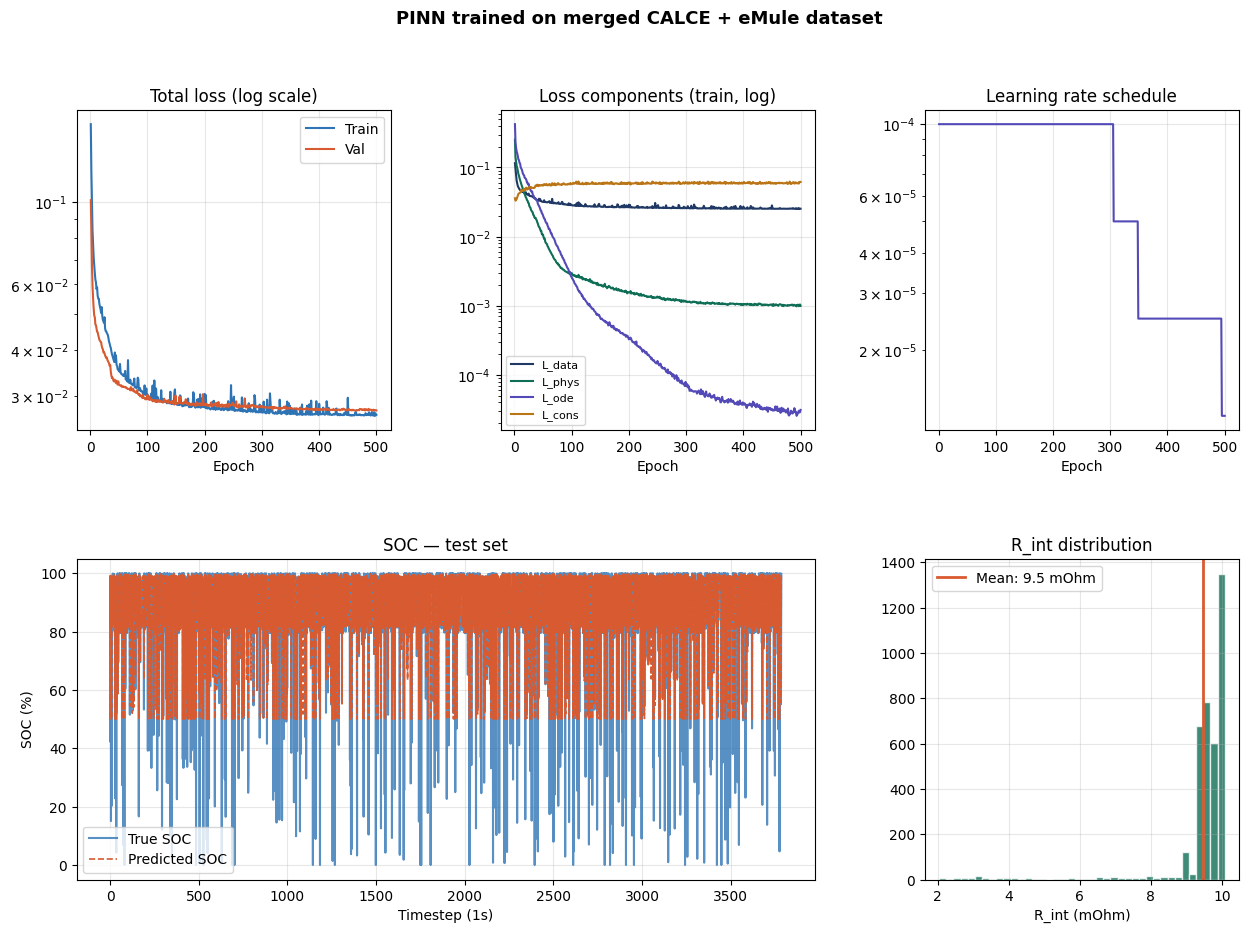

Plot saved → ./pinn_checkpoint_merged/merged_results.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 10))
fig.suptitle("PINN trained on merged CALCE + eMule dataset", fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

epochs_ran = range(1, len(trainer.history['train_total']) + 1)

# Panel 1 — Total loss
ax = fig.add_subplot(gs[0, 0])
ax.semilogy(epochs_ran, trainer.history['train_total'], label='Train', color='#2E74B5')
ax.semilogy(epochs_ran, trainer.history['val_total'],   label='Val',   color='#D85A30')
ax.set_title("Total loss (log scale)")
ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)

# Panel 2 — Loss components
ax = fig.add_subplot(gs[0, 1])
colors = {"data":"#1F3864","phys":"#0F6E56","ode":"#534AB7","cons":"#BA7517"}
for k, c in colors.items():
    ax.semilogy(epochs_ran, trainer.history[f'train_{k}'], label=f'L_{k}', color=c, lw=1.5)
ax.set_title("Loss components (train, log)")
ax.set_xlabel("Epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 3 — Learning rate
ax = fig.add_subplot(gs[0, 2])
ax.semilogy(epochs_ran, trainer.history['lr'], color='#534AB7')
ax.set_title("Learning rate schedule")
ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)

# Panel 4 — SOC prediction
ax = fig.add_subplot(gs[1, 0:2])
if hasattr(trainer, '_soc_pred'):
    t = range(len(trainer._soc_true))
    ax.plot(t, trainer._soc_true.flatten(), label='True SOC',      color='#2E74B5', lw=1.5, alpha=0.8)
    ax.plot(t, trainer._soc_pred.flatten(), label='Predicted SOC', color='#D85A30', lw=1.2, ls='--')
    ax.set_title("SOC — test set")
    ax.set_xlabel("Timestep (1s)"); ax.set_ylabel("SOC (%)")
    ax.legend(); ax.grid(alpha=0.3)

# Panel 5 — R_int distribution
ax = fig.add_subplot(gs[1, 2])
if hasattr(trainer, '_r_int'):
    r_mOhm = trainer._r_int.flatten() * 1000
    ax.hist(r_mOhm, bins=40, color='#0F6E56', alpha=0.8, edgecolor='white')
    ax.axvline(r_mOhm.mean(), color='#D85A30', lw=2,
               label=f'Mean: {r_mOhm.mean():.1f} mOhm')
    ax.set_title("R_int distribution")
    ax.set_xlabel("R_int (mOhm)"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CHECKPOINT}/merged_results.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved → {CHECKPOINT}/merged_results.png")


### Cell 11 — Save model checkpoint

In [23]:
trainer.save(CHECKPOINT)
print(f"Model saved → {CHECKPOINT}/")
print()
print("Files created:")
for f in sorted(Path(CHECKPOINT).iterdir()):
    size = f.stat().st_size
    print(f"  {f.name:<35} {size/1024:.1f} KB")


15:03:21  INFO      Config saved → pinn_checkpoint_merged\config.json
15:03:21  INFO      Checkpoint saved → pinn_checkpoint_merged/


Model saved → ./pinn_checkpoint_merged/

Files created:
  config.json                         0.6 KB
  history.json                        138.7 KB
  merged_results.png                  311.7 KB
  model_weights.pt                    214.4 KB
  test_r_int.npy                      14.9 KB
  test_soc_pred.npy                   14.9 KB
  test_soc_true.npy                   14.9 KB
  test_v_oc.npy                       14.9 KB
